In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
# ---------------------------------------------------------
#  Load the (cleaned) dataset
# ---------------------------------------------------------
df = pd.read_csv("iris_cleaned.csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
142,6.7,3.0,5.2,2.3,virginica
143,6.3,2.5,5.0,1.9,virginica
144,6.5,3.0,5.2,2.0,virginica
145,6.2,3.4,5.4,2.3,virginica


In [6]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
 
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(df.head())

DATASET OVERVIEW
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [11]:
print(f"\nShape: {df.shape}")


Shape: (147, 5)


In [10]:
print(f"\nSpecies counts:\n{df['species'].value_counts()}")


Species counts:
species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64


In [13]:
# ---------------------------------------------------------
# Summary statistics: mean, median, mode, std
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
 
summary = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "mode": df[numeric_cols].mode().iloc[0],
    "std_dev": df[numeric_cols].std(),
    "min": df[numeric_cols].min(),
    "max": df[numeric_cols].max(),
})
print(summary)
summary.to_csv("eda_summary_statistics.csv")
print("\nSaved summary statistics to eda_summary_statistics.csv")


SUMMARY STATISTICS
                  mean  median  mode   std_dev  min  max
sepal_length  5.856463     5.8   5.0  0.829100  4.3  7.9
sepal_width   3.055782     3.0   3.0  0.437009  2.0  4.4
petal_length  3.780272     4.4   1.4  1.759111  1.0  6.9
petal_width   1.208844     1.3   0.2  0.757874  0.1  2.5

Saved summary statistics to eda_summary_statistics.csv


In [14]:
# Per-species summary too, since it adds real insight for this dataset
print("\nMean measurements grouped by species:")
print(df.groupby("species")[numeric_cols].mean())


Mean measurements grouped by species:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          5.010417     3.431250      1.462500     0.250000
versicolor      5.936000     2.770000      4.260000     1.326000
virginica       6.604082     2.979592      5.561224     2.028571


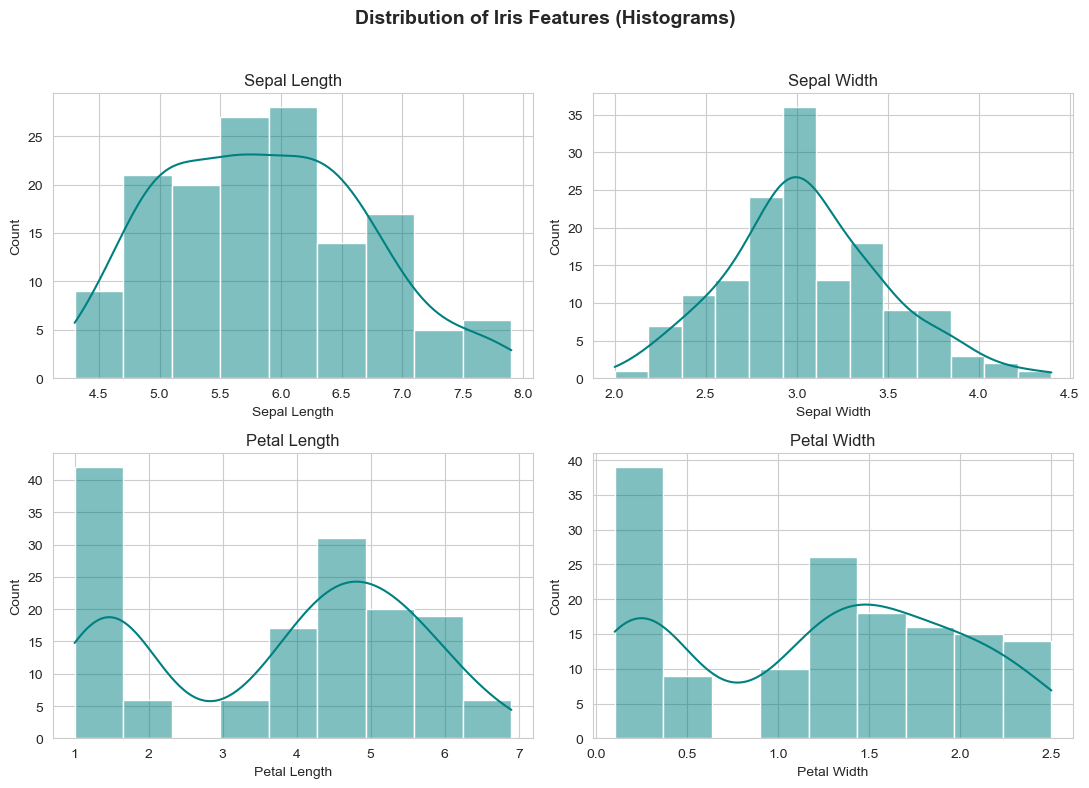

Saved eda_histograms.png


In [15]:
# ---------------------------------------------------------
#  Visualizations
# ---------------------------------------------------------
 
# --- Histograms: distribution of each numeric feature ---
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle("Distribution of Iris Features (Histograms)", fontsize=14, fontweight="bold")
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="teal")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col.replace("_", " ").title())
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("eda_histograms.png", dpi=150)
plt.show()
print("Saved eda_histograms.png")

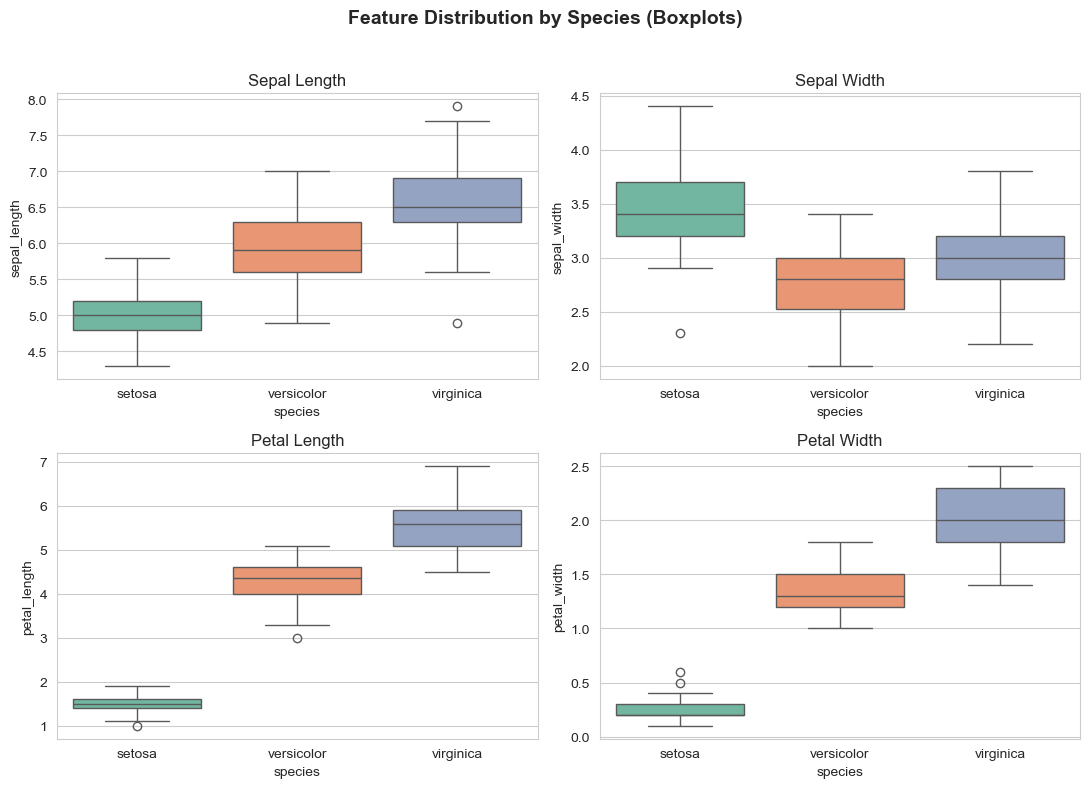

Saved eda_boxplots.png


In [16]:
# --- Boxplots: spread & outliers per feature, split by species ---
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle("Feature Distribution by Species (Boxplots)", fontsize=14, fontweight="bold")
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(data=df, x="species", y=col, ax=ax, hue="species", legend=False, palette="Set2")
    ax.set_title(col.replace("_", " ").title())
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("eda_boxplots.png", dpi=150)
plt.show()
print("Saved eda_boxplots.png")

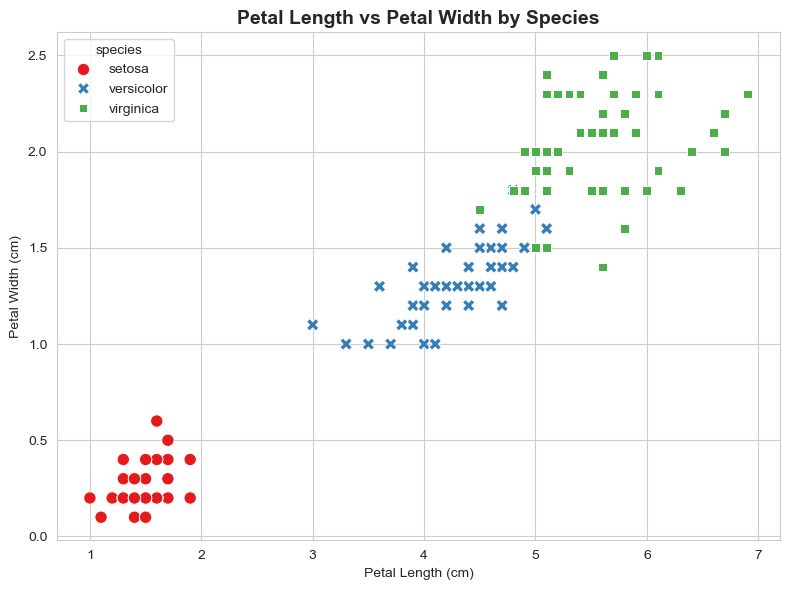

Saved eda_scatter_petal.png


In [17]:
# --- Scatter plot: relationship between two key features ---
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="petal_length", y="petal_width",
    hue="species", style="species", s=80, palette="Set1"
)
plt.title("Petal Length vs Petal Width by Species", fontsize=14, fontweight="bold")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.tight_layout()
plt.savefig("eda_scatter_petal.png", dpi=150)
plt.show()
print("Saved eda_scatter_petal.png")

In [20]:
# ---------------------------------------------------------
# Correlation between numerical features
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)
corr = df[numeric_cols].corr()
print(corr)
corr.to_csv("eda_correlation_matrix.csv")



CORRELATION MATRIX
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109321      0.871305     0.817058
sepal_width      -0.109321     1.000000     -0.421057    -0.356376
petal_length      0.871305    -0.421057      1.000000     0.961883
petal_width       0.817058    -0.356376      0.961883     1.000000


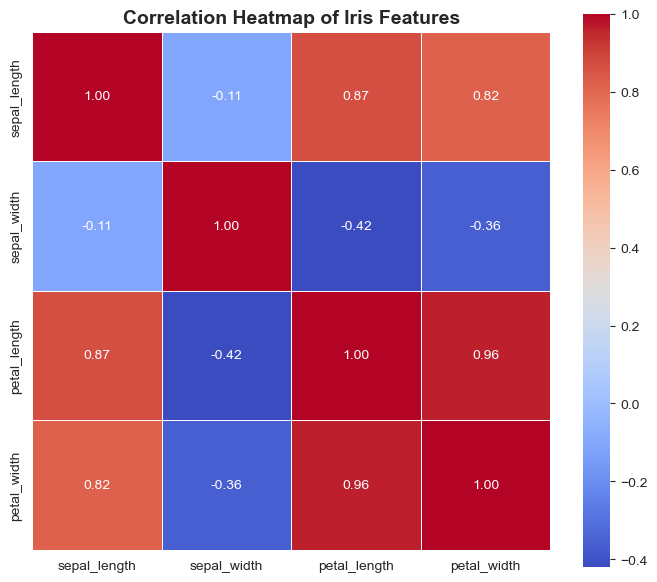

Saved eda_correlation_heatmap.png


In [19]:
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Iris Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150)
plt.show()
print("Saved eda_correlation_heatmap.png")

In [21]:
print("\nEDA complete. All plots and summary files have been saved.")


EDA complete. All plots and summary files have been saved.
